In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time

In [2]:
def get_historical_data(symbol, interval='60', num_candles=3000):
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []
    end = int(time.time() * 1000)

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def analyse_pair(symbol_a, symbol_b):
    df_a = get_historical_data(symbol_a)
    df_b = get_historical_data(symbol_b)
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    _, pvalue, _ = coint(price_a, price_b)
    print(f"cointegration p-value: {pvalue:.4f}")
    timestamps = df_a['timestamp']
    plt.plot(timestamps, price_a / price_a[0], label=symbol_a)
    plt.plot(timestamps, price_b / price_b[0], label=symbol_b)
    plt.legend()
    plt.title('prices')
    plt.xticks(rotation=45)
    plt.show()

    beta = np.cov(price_a, price_b)[0, 1] / np.var(price_b)
    alpha = np.mean(price_a) - beta * np.mean(price_b)

    spread = price_a - alpha - beta * price_b
    plt.plot(timestamps, spread)
    plt.title('spread')
    plt.xticks(rotation=45)
    plt.show()

    zscore = (spread - spread.mean()) / spread.std()
    plt.plot(timestamps, zscore)
    plt.axhline(2, color='red', linestyle='--', label='short signal')
    plt.axhline(-2, color='green', linestyle='--', label='long signal')
    plt.axhline(0, color='gray', linestyle=':')
    plt.legend()
    plt.title('z-score')
    plt.xticks(rotation=45)
    plt.show()

In [3]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

598
['BABYDOGEUSDT', 'VIRTUALMNT', 'LBTCUSDT', 'BTCUSD1', 'ARUSDT', 'XUSDUSDT', 'ELIZAOSUSDT', 'NXPCMNT', 'CARVUSDT', 'CYBERUSDT', 'XANUSDT', 'MNTUSDT', 'USDTUSD', 'ZBTUSDT', 'BEAMUSDT', 'SCORUSDT', 'ATHUSDT', 'FILUSDC', 'ZKCUSDT', 'BREVUSDT', 'TOKENUSDT', 'ADAUSDC', 'USDTBUSDT', '2ZUSDT', 'ENAUSDC', 'CAMPUSDT', 'SUIUSDT', 'WCTUSDT', 'LINKUSDC', 'ENSUSDT', 'TRUMPUSDC', 'COINXUSDT', 'MOVEUSDT', 'FRAXUSDT', 'MCRTUSDT', 'ALCHUSDT', 'PEPEUSDC', 'MNTUSDE', 'BABY1USDT', 'CAKEUSDT', 'SEIUSDC', 'LRCUSDT', 'CUDISUSDT', 'SUPRAUSDT', 'CELOUSDT', 'RESOLVUSDT', 'XRPEUR', 'VELOUSDT', 'PLUMEUSDT', 'COOKUSDT']


In [4]:
btc = get_historical_data('BTCUSDT')
eth = get_historical_data('ETHUSDT')
sol = get_historical_data('SOLUSDT')
btc.head()

,timestamp,close
0,2026-02-27 23:00:00,65868.2
1,2026-02-28 00:00:00,65938.3
2,2026-02-28 01:00:00,65768.4
3,2026-02-28 02:00:00,65953.2
4,2026-02-28 03:00:00,65788.9


In [5]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.7479
BTC|SOL: 0.9562
ETH|SOL: 0.9321


In [6]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

431
['BABYDOGEUSDT', 'LBTCUSDT', 'ARUSDT', 'XUSDUSDT', 'ELIZAOSUSDT', 'CARVUSDT', 'CYBERUSDT', 'XANUSDT', 'MNTUSDT', 'ZBTUSDT', 'BEAMUSDT', 'SCORUSDT', 'ATHUSDT', 'ZKCUSDT', 'BREVUSDT', 'TOKENUSDT', 'USDTBUSDT', '2ZUSDT', 'CAMPUSDT', 'SUIUSDT', 'WCTUSDT', 'ENSUSDT', 'COINXUSDT', 'MOVEUSDT', 'FRAXUSDT', 'MCRTUSDT', 'ALCHUSDT', 'BABY1USDT', 'CAKEUSDT', 'LRCUSDT', 'CUDISUSDT', 'SUPRAUSDT', 'CELOUSDT', 'RESOLVUSDT', 'VELOUSDT', 'PLUMEUSDT', 'COOKUSDT', 'KAIAUSDT', 'HBARUSDT', 'PEPEUSDT', 'NEWTUSDT', 'MBXUSDT', 'CBKUSDT', 'VETUSDT', 'ADAUSDT', 'POLUSDT', 'WETUSDT', 'BLASTUSDT', 'ROBOUSDT', 'LINEAUSDT']


In [7]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'BABYDOGEUSDT', 'bid1Price': '0.0000000002964', 'bid1Size': '2427921092564', 'ask1Price': '0.000000000297', 'ask1Size': '82509834059', 'lastPrice': '0.0000000002962', 'prevPrice24h': '0.000000000295', 'price24hPcnt': '0.0041', 'highPrice24h': '0.0000000003018', 'lowPrice24h': '0.0000000002896', 'turnover24h': '30893.73018885138464', 'volume24h': '103992635895781.2', 'usdIndexPrice': '0.000000000296'}


In [8]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

91
['MNTUSDT', 'ZBTUSDT', 'BREVUSDT', 'SUIUSDT', 'COINXUSDT', 'HBARUSDT', 'PEPEUSDT', 'ADAUSDT', 'WETUSDT', 'CCUSDT', 'TSLAXUSDT', 'SPCXXUSDT', 'FLUIDUSDT', 'ARXUSDT', 'MORPHOUSDT', 'ENAUSDT', 'SPXUSDT', 'SOLUSDT', 'WLDUSDT', 'ASTERUSDT', 'AEROUSDT', 'METUSDT', 'STRKUSDT', 'VVVUSDT', 'MEGAUSDT', 'MONUSDT', 'EIGENUSDT', 'NIGHTUSDT', 'CRCLXUSDT', 'SLXUSDT', 'PENGUUSDT', 'BIRBUSDT', 'CLOUDUSDT', 'USD1USDT', 'DEEPUSDT', 'SHIBUSDT', 'XAUTUSDT', 'CAPUSDT', 'TRUMPUSDT', 'ICPUSDT', 'IPUSDT', 'BCHUSDT', 'ZIGUSDT', 'XPLUSDT', 'FETUSDT', 'TRXUSDT', 'HYPEUSDT', 'ETHUSDT', 'XRPUSDT', 'MEUSDT']


In [9]:
data = {}
for ticker in tickers_filt:
    data[ticker] = get_historical_data(ticker)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data[a]), len(data[b]))
            _, pvalue, _ = coint(data[a]['close'].iloc[:n], data[b]['close'].iloc[:n])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

       ticker_a   ticker_b    pvalue
1590  ASTERUSDT   PUMPUSDT  0.000004
125     ZBTUSDT    CAPUSDT  0.000007
3321    TACUSDT    JTOUSDT  0.000020
806      CCUSDT    ZIGUSDT  0.000046
787      CCUSDT    VVVUSDT  0.000048
1937   MEGAUSDT   BILLUSDT  0.000052
819      CCUSDT   ONDOUSDT  0.000054
1592  ASTERUSDT    SEIUSDT  0.000059
1575  ASTERUSDT    DOTUSDT  0.000062
844      CCUSDT   NEARUSDT  0.000075
830      CCUSDT      HUSDT  0.000086
851      CCUSDT    INJUSDT  0.000088
848      CCUSDT   GRAMUSDT  0.000097
1547  ASTERUSDT  CRCLXUSDT  0.000106
3346    TACUSDT    JUPUSDT  0.000140
854      CCUSDT   USDEUSDT  0.000184
818      CCUSDT   AAVEUSDT  0.000194
1596  ASTERUSDT    UNIUSDT  0.000213
814      CCUSDT     FFUSDT  0.000219
807      CCUSDT    XPLUSDT  0.000229


In [10]:
print(len(strong))
print(strong.to_string())

197
       ticker_a     ticker_b    pvalue
1590  ASTERUSDT     PUMPUSDT  0.000004
125     ZBTUSDT      CAPUSDT  0.000007
3321    TACUSDT      JTOUSDT  0.000020
806      CCUSDT      ZIGUSDT  0.000046
787      CCUSDT      VVVUSDT  0.000048
1937   MEGAUSDT     BILLUSDT  0.000052
819      CCUSDT     ONDOUSDT  0.000054
1592  ASTERUSDT      SEIUSDT  0.000059
1575  ASTERUSDT      DOTUSDT  0.000062
844      CCUSDT     NEARUSDT  0.000075
830      CCUSDT        HUSDT  0.000086
851      CCUSDT      INJUSDT  0.000088
848      CCUSDT     GRAMUSDT  0.000097
1547  ASTERUSDT    CRCLXUSDT  0.000106
3346    TACUSDT      JUPUSDT  0.000140
854      CCUSDT     USDEUSDT  0.000184
818      CCUSDT     AAVEUSDT  0.000194
1596  ASTERUSDT      UNIUSDT  0.000213
814      CCUSDT       FFUSDT  0.000219
807      CCUSDT      XPLUSDT  0.000229
774      CCUSDT    TSLAXUSDT  0.000251
832      CCUSDT      NOMUSDT  0.000252
1584  ASTERUSDT      BNBUSDT  0.000257
765     WETUSDT      ZROUSDT  0.000291
1555  ASTERUSDT     X

In [11]:
tickers_liquid = [t_info['symbol'] for t_info in r.json()['result']['list']
               if float(t_info['turnover24h']) > 10_000_000
               and t_info['symbol'].endswith('USDT')]
print(len(tickers_liquid))
print(tickers_liquid)

12
['MNTUSDT', 'ARXUSDT', 'SOLUSDT', 'SLXUSDT', 'BIRBUSDT', 'HYPEUSDT', 'ETHUSDT', 'XRPUSDT', 'USDCUSDT', 'TAIKOUSDT', 'BTCUSDT', 'LITUSDT']


In [12]:
data = {}
for ticker in tickers_liquid:
    data[ticker] = get_historical_data(ticker)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data[a]), len(data[b]))
            _, pvalue, _ = coint(data[a]['close'].iloc[:n], data[b]['close'].iloc[:n])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
print(len(strong))
print(strong.to_string())

6
    ticker_a  ticker_b    pvalue
22   SOLUSDT  BIRBUSDT  0.005544
39  BIRBUSDT   ETHUSDT  0.021398
40  BIRBUSDT   XRPUSDT  0.001875
44  BIRBUSDT   LITUSDT  0.023310
55   ETHUSDT   LITUSDT  0.038291
59   XRPUSDT   LITUSDT  0.009174


SOLUSDT|BIRBUSDT
cointegration p-value: 0.0055


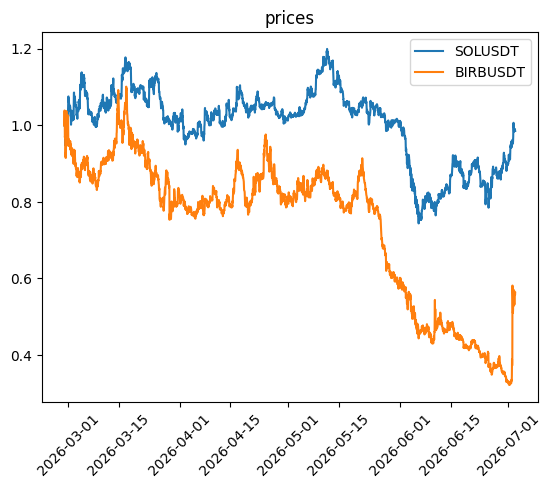

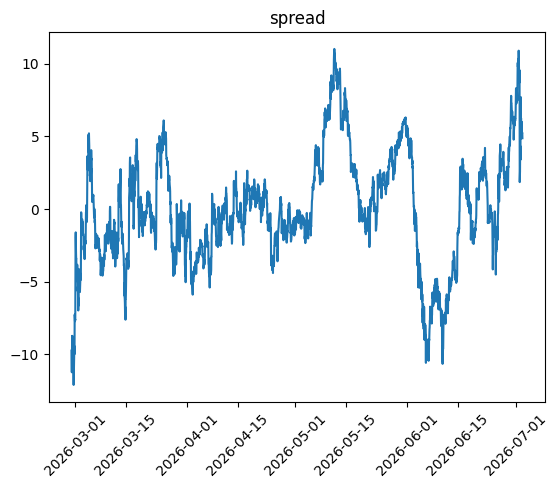

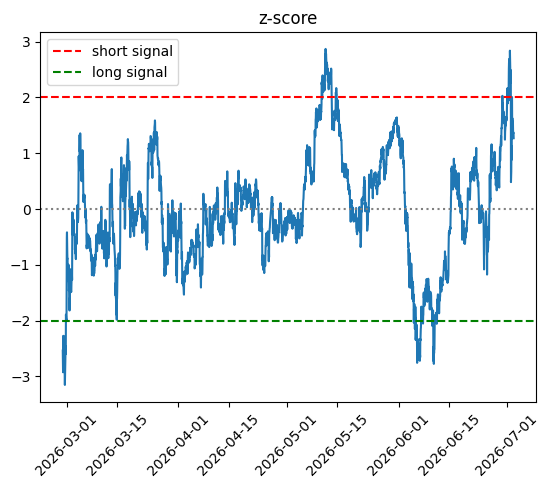

BIRBUSDT|ETHUSDT
cointegration p-value: 0.0214


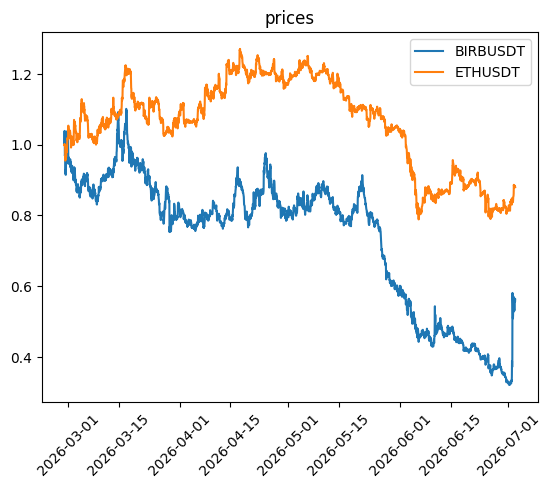

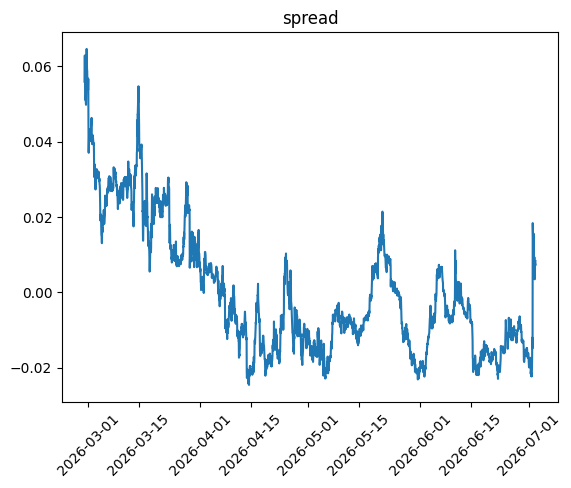

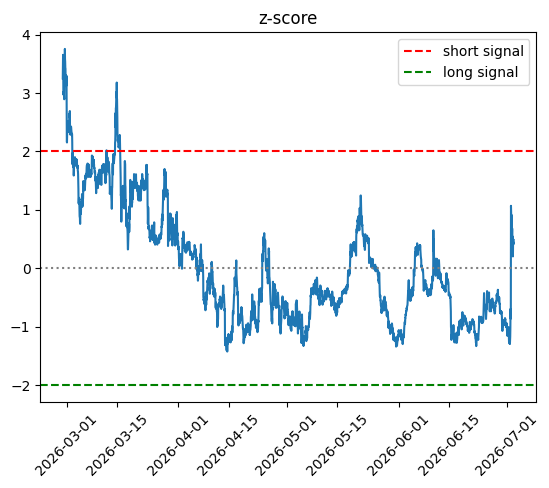

BIRBUSDT|XRPUSDT
cointegration p-value: 0.0019


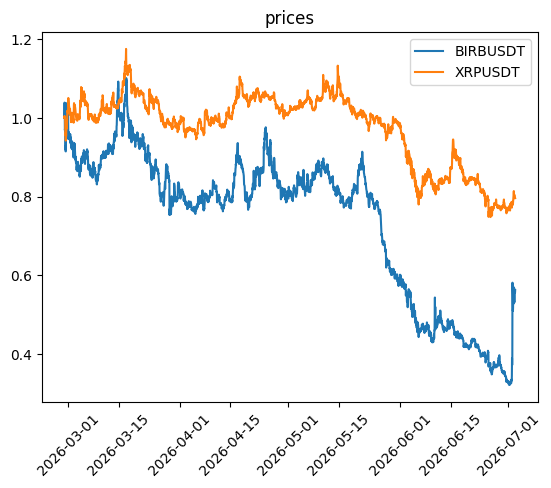

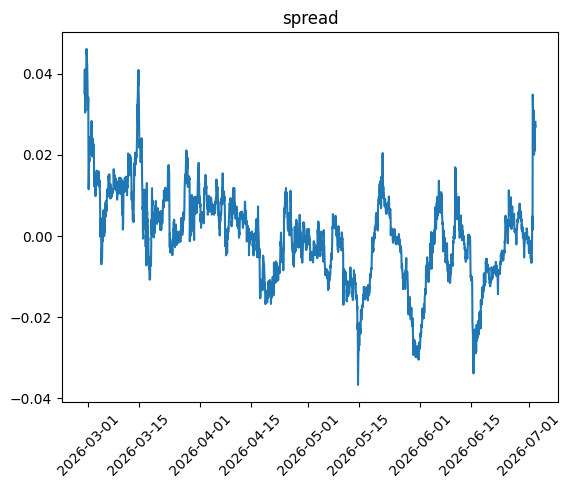

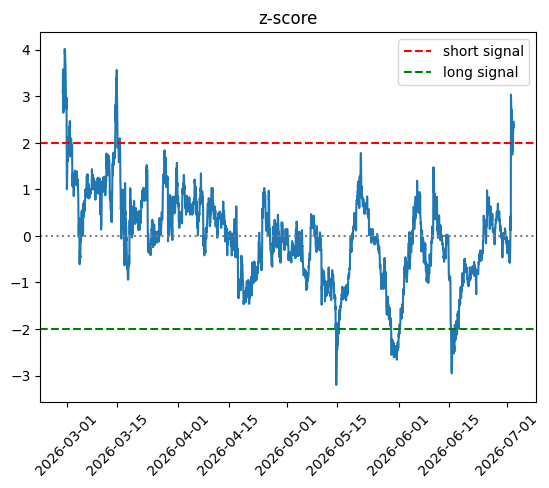

BIRBUSDT|LITUSDT
cointegration p-value: 0.0232


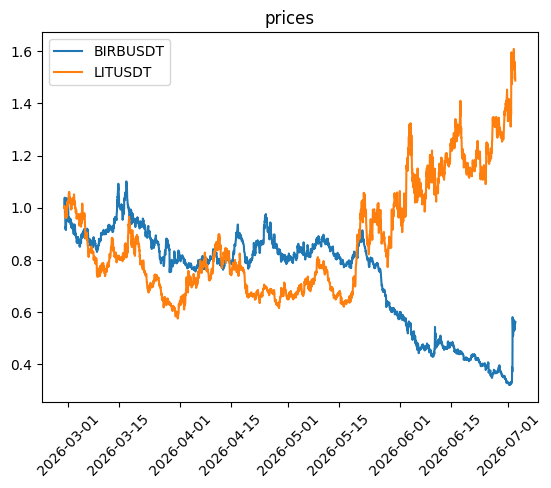

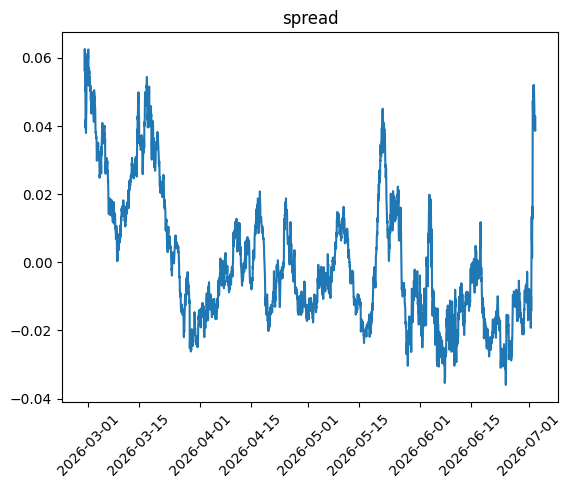

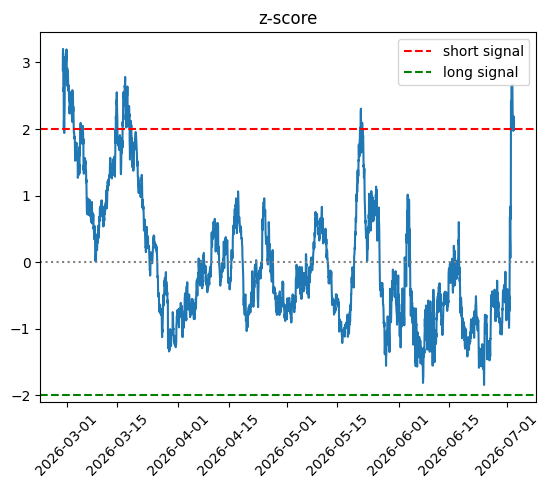

ETHUSDT|LITUSDT
cointegration p-value: 0.0381


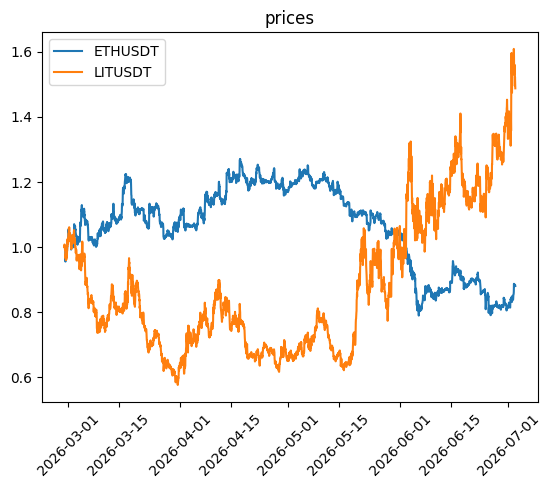

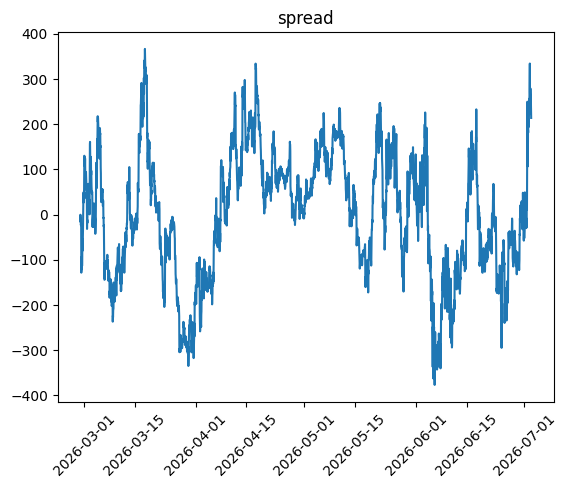

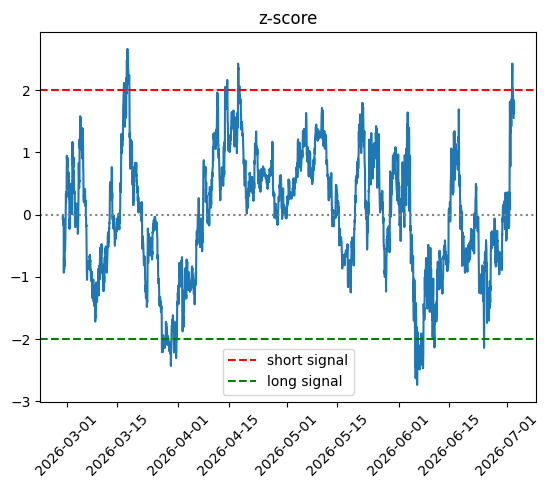

XRPUSDT|LITUSDT
cointegration p-value: 0.0092


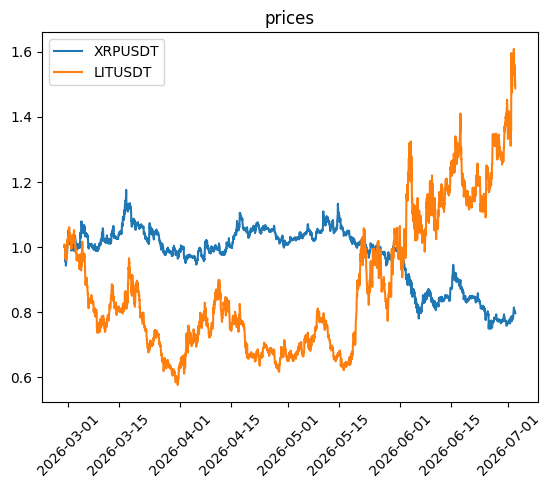

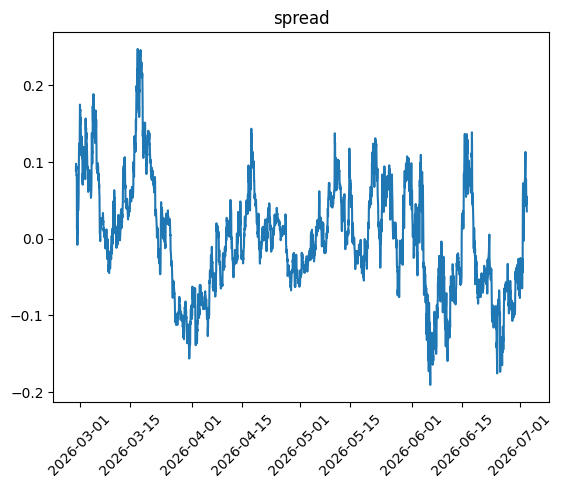

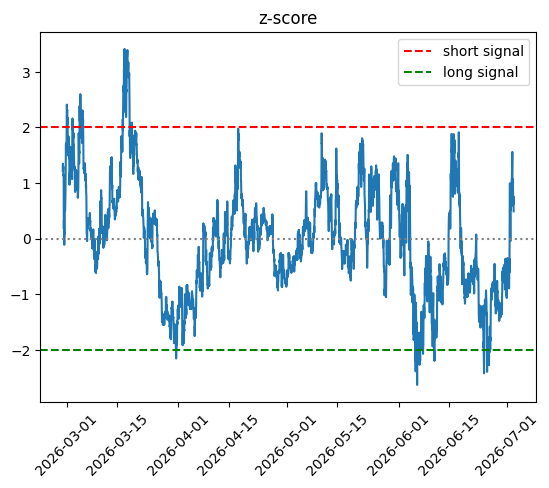

In [13]:
for ticker_a, ticker_b in zip(strong['ticker_a'], strong['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b)